# 📊 Voorspelling Jeugdpopulatie Almere (2019–2025)
## Gemeente Notebook
*Dit notebook bevat het volledige CRISP-DM proces: van probleemdefinitie tot evaluatie.*

Voor dit onderzoek gebruiken we historische data van het CBS (Wijken en buurten; kerncijfers). Deze dataset bevat demografische informatie per wijk, zoals het aantal inwoners en het aantal jongeren per leeftijdscategorie.

In dit notebook worden de data eerst verkend en opgeschoond, daarna geanalyseerd en uiteindelijk gebruikt om een voorspellend model te bouwen. Het doel is om inzicht te krijgen in de ontwikkeling van jongeren in Almere en trends zichtbaar te maken die relevant zijn voor toekomstig beleid.

## Business Understanding
**Probleem:**

De gemeente Almere beschikt over historische gegevens over de bevolkingssamenstelling per wijk, maar heeft nog geen model dat toekomstige ontwikkelingen van de jeugdpopulatie kan voorspellen. Hierdoor ontbreekt een datagedreven onderbouwing voor het plannen van voorzieningen zoals scholen, jongerenvoorzieningen en jeugdzorg.

Zonder inzicht in toekomstige ontwikkelingen bestaat het risico dat voorzieningen niet goed aansluiten op de vraag in verschillende wijken.

**Doel:**

De ontwikkeling van de jeugdpopulatie heeft directe invloed op voorzieningen in de stad. Wanneer het aantal jongeren in een wijk groeit, kan dit leiden tot een grotere behoefte aan scholen, sportvoorzieningen en jeugdzorg.

Door trends in de jeugdpopulatie tijdig te signaleren kan de gemeente Almere beter plannen en middelen efficiënter inzetten. Datagedreven inzichten helpen beleidsmakers om toekomstige ontwikkelingen beter te onderbouwen en voorbereid te zijn op veranderingen in de stad.

**Waarom is dit belangrijk?**

De ontwikkeling van de jeugdpopulatie heeft directe invloed op voorzieningen in de stad. Wanneer het aantal jongeren in een wijk groeit, kan dit leiden tot een grotere behoefte aan scholen, sportvoorzieningen en jeugdzorg.

Door trends in de jeugdpopulatie tijdig te signaleren kan de gemeente Almere beter plannen en middelen efficiënter inzetten. Datagedreven inzichten helpen beleidsmakers om toekomstige ontwikkelingen beter te onderbouwen en voorbereid te zijn op veranderingen in de stad.

--------------------

# Data Preparation – Fase 1

In deze eerste fase van de data preparation wordt de ruwe CBS-dataset ingelezen en verkend. Het doel van deze stap is om inzicht te krijgen in de structuur en kwaliteit van de data voordat verdere analyses worden uitgevoerd.

We beginnen met een eerste verkenning van de dataset. Hierbij kijken we naar het aantal rijen en kolommen, de beschikbare variabelen, de datatypes en mogelijke ontbrekende waarden. Deze stap helpt om te begrijpen hoe de data is opgebouwd en welke voorbereidingen nodig zijn voor verdere analyse.

De dataset bevat demografische gegevens per regio, waaronder het aantal inwoners en de verdeling van inwoners over verschillende leeftijdscategorieën. Omdat dit onderzoek zich specifiek richt op de jeugdpopulatie in Almere, zullen we in de volgende stappen de dataset filteren op deze gemeente en op wijkniveau.

Het doel van deze fase is om een opgeschoonde dataset te verkrijgen die geschikt is voor verdere analyse in de volgende stappen van het project.

### **Inladen van de dataset**

In deze stap importeren we de benodigde Python-libraries voor data-analyse en visualisatie. Vervolgens wordt de ruwe CBS-dataset ingeladen. Met `shape` bekijken we de grootte van de dataset en met `head()` krijgen we een eerste indruk van de structuur en inhoud van de data.

In [ ]:
# importeren van benodigde libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Ruwe CBS dataset inladen
df_cbs = pd.read_csv("../../data/raw/CBS_Kerncijfers.csv", sep=";")

print("Shape:", df_cbs.shape)
df_cbs.head()

Shape: (1536, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
0,384,1-1-2025,GM0034,Almere,Gemeente,GM0034,1.0,229574,113738,115836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,386,1-1-2025,BU00340101,Almere,Buurt,BU00340101,1.0,795,415,385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,387,1-1-2025,BU00340102,Almere,Buurt,BU00340102,1.0,1010,465,545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Eerste indruk van de dataset**

De eerste rijen van de dataset laten zien dat de data bevolkingsinformatie bevat per gemeente, wijk en buurt. Voor dit onderzoek zijn de rijen op wijkniveau relevant, omdat we verschillen tussen wijken in Almere willen analyseren.  

De dataset bevat veel variabelen (411 kolommen), waaronder het aantal inwoners, geslacht, leeftijdsgroepen en verschillende sociaal-economische indicatoren. In de volgende stappen wordt de dataset gefilterd op gemeente Almere en op wijkniveau, zodat alleen de relevante gegevens overblijven.

## Data Preparation FASE 1


### **Overzicht van de dataset**

**Eerste verkenning (Wail + Faysal)**

In deze stap verkennen we de structuur van de dataset. We bekijken de kolommen, datatypes en basisstatistieken om een eerste beeld te krijgen van de beschikbare gegevens. Daarnaast analyseren we het aantal missende waarden per kolom en het percentage ontbrekende data.


In [783]:
# Overzicht: kolommen, types, missende waarden
df_cbs.info()

# Beschrijvende statistiek (numeriek)
df_cbs.describe()
# Missende waarden overzicht (aantallen + percentages)
missing_counts = df_cbs.isnull().sum()
missing_pct = (missing_counts / len(df_cbs)) * 100

missing_overview = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct
}).sort_values("missing_percentage", ascending=False)

missing_overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Columns: 411 entries, ID to GeweldsEnSeksueleMisdrijven_90
dtypes: float64(387), int64(13), object(11)
memory usage: 4.8+ MB


,missing_count,missing_percentage
HJVervoerInformatieEnCommunicatie_101,1536,100.0
GemiddeldeElektriciteitsleveringTotaal_53,1536,100.0
PersonenPerSoortUitkeringBijstand_89,1536,100.0
PersonenPerSoortUitkeringAO_90,1536,100.0
PersonenPerSoortUitkeringWW_91,1536,100.0
...,...,...
Gehuwd_14,0,0.0
Gescheiden_15,0,0.0
Verweduwd_16,0,0.0
Peildatum,0,0.0


**Toelichting**

Uit de analyse blijkt dat de dataset een groot aantal variabelen bevat en dat sommige kolommen veel missende waarden hebben. Dit is deels te verklaren doordat de dataset verschillende soorten regio’s bevat, zoals gemeenten, wijken en buurten, waarbij niet alle indicatoren voor elk niveau beschikbaar zijn.  

Door dit overzicht krijgen we inzicht in de kwaliteit van de data en kunnen we bepalen welke variabelen relevant zijn voor het verdere onderzoek en welke eventueel moeten worden opgeschoond of verwijderd.

### **Filter op Almere en op wijken (Ismael)**

In deze stap wordt de dataset opgeschoond en gefilterd zodat alleen de relevante gegevens voor dit onderzoek overblijven. Eerst worden kolomnamen en tekstvelden opgeschoond om eventuele spaties te verwijderen. Vervolgens wordt de dataset gefilterd op de gemeente Almere. Daarna wordt verder gefilterd op regio’s van het type wijk, omdat dit onderzoek zich richt op verschillen tussen wijken binnen Almere.

In [784]:
# kolomnamen opschonen
df_cbs.columns = df_cbs.columns.astype(str).str.strip()

# gemeentenaam opschonen
df_cbs["Gemeentenaam_1"] = df_cbs["Gemeentenaam_1"].astype(str).str.strip()

# filter Almere
df_almere = df_cbs[df_cbs["Gemeentenaam_1"] == "Almere"].copy()
print("Shape Almere:", df_almere.shape)

# waardes opschonen + filter wijken
df_almere["SoortRegio_2"] = df_almere["SoortRegio_2"].astype(str).str.strip()
df_almere["Codering_3"] = df_almere["Codering_3"].astype(str).str.strip()

df_wijk = df_almere[df_almere["SoortRegio_2"] == "Wijk"].copy()
df_wijk = df_wijk[df_wijk["Codering_3"].str.startswith("WK")].copy()

print("Shape wijken:", df_wijk.shape)
df_wijk.head()

Shape Almere: (1536, 411)
Shape wijken: (308, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,394,1-1-2025,WK003403,Almere,Wijk,WK003403,1.0,2500,1205,1300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,399,1-1-2025,WK003404,Almere,Wijk,WK003404,1.0,2220,1065,1155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,403,1-1-2025,WK003405,Almere,Wijk,WK003405,1.0,2365,1130,1235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Toelichting**

Na het filteren bevat de dataset 1536 rijen voor de gemeente Almere. Wanneer vervolgens alleen de regio’s van het type wijk worden geselecteerd, blijven er 308 rijen over. Deze rijen bevatten de demografische gegevens per wijk en per jaar. Deze gefilterde dataset vormt de basis voor de verdere analyses in het onderzoek.

### **Basis datakwaliteit checks (Wail + Noah + Ismael)**

In deze stap controleren we de kwaliteit en volledigheid van de wijkdata. We kijken of er dubbele rijen of dubbele combinaties van wijkcode en peildatum voorkomen. Daarnaast controleren we hoeveel unieke wijken er in de dataset zitten en of voor elke wijk alle jaren aanwezig zijn.

In [785]:
# Dubbele combinaties wijkcode + peildatum
dup_count = df_wijk.duplicated(subset=["Codering_3", "Peildatum"]).sum()
print("Duplicaten (Codering_3 + Peildatum):", dup_count)

# Volledig dubbele rijen
full_dup = df_wijk.duplicated().sum()
print("Volledig dubbele rijen:", full_dup)

# Unieke wijken
print("Aantal unieke wijken:", df_wijk["Codering_3"].nunique())

# Aantal jaren per wijk
jaren_per_wijk = df_wijk.groupby("Codering_3")["Peildatum"].nunique()
jaren_per_wijk.describe()

# Missende jaren per wijk
alle_jaren = sorted(df_wijk["Peildatum"].dropna().unique())

print("Missende jaren per wijk (alleen wijken met missende jaren):")
for wijk, groep in df_wijk.groupby("Codering_3"):
    aanwezige = sorted(groep["Peildatum"].dropna().unique())
    missend = sorted(set(alle_jaren) - set(aanwezige))
    if missend:
        print(f"{wijk} mist: {missend}")

Duplicaten (Codering_3 + Peildatum): 0
Volledig dubbele rijen: 0
Aantal unieke wijken: 71
Missende jaren per wijk (alleen wijken met missende jaren):
WK003407 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003408 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003409 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003410 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003411 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003414 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003415 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003416 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003417 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003418 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003419 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003420 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003421 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003422 mist: ['1

**Toelichting**

Uit de controle blijkt dat er geen dubbele combinaties van wijkcode en peildatum zijn en ook geen volledig dubbele rijen. Dat betekent dat de dataset op dit punt consistent is. Verder bevat de dataset 71 unieke wijken.

Wel blijkt dat meerdere wijken de jaren 2018 tot en met 2021 missen. Dit wijst erop dat niet alle wijken in alle jaren voorkomen, waarschijnlijk door wijzigingen in de wijkindeling of doordat sommige wijken pas later zijn toegevoegd. Dit is belangrijk om mee te nemen in de verdere analyse en modellering.

### **Kernvariabelen opschonen (Bo + Faysal)**

In deze stap worden de belangrijkste variabelen voor het onderzoek opgeschoond. De kolommen voor het totaal aantal inwoners, het aantal inwoners van 0–15 jaar en het aantal inwoners van 15–25 jaar worden omgezet naar numerieke waarden. Daarna worden rijen met ontbrekende waarden en nulwaarden verwijderd, zodat alleen bruikbare observaties overblijven voor de verdere analyse.

In [786]:
cols_check = ["AantalInwoners_5", "k_0Tot15Jaar_8", "k_15Tot25Jaar_9"]

# naar numeriek
for col in cols_check:
    df_wijk[col] = pd.to_numeric(df_wijk[col], errors="coerce")

# NaN eruit
df_wijk = df_wijk.dropna(subset=cols_check)

# 0-waarden eruit
for col in cols_check:
    df_wijk = df_wijk[df_wijk[col] != 0]

print("Shape na opschonen kernvariabelen:", df_wijk.shape)
df_wijk[cols_check].describe()

# Extra logische checks (Faysel)
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"

checks = {
    "negatief_0_15": (df_wijk[kol_0_15] < 0).sum(),
    "negatief_15_25": (df_wijk[kol_15_25] < 0).sum(),
    "negatief_totaal": (df_wijk[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df_wijk[kol_0_15] > df_wijk[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df_wijk[kol_15_25] > df_wijk[kol_totaal]).sum(),
}
checks

Shape na opschonen kernvariabelen: (237, 411)


{'negatief_0_15': np.int64(0),
 'negatief_15_25': np.int64(0),
 'negatief_totaal': np.int64(0),
 '0_15_groter_dan_totaal': np.int64(0),
 '15_25_groter_dan_totaal': np.int64(0)}

**Toelichting**

Na het opschonen blijven er 237 rijen in de dataset over. Daarnaast laten de logische controles zien dat er geen negatieve waarden voorkomen en dat het aantal jongeren nooit groter is dan het totaal aantal inwoners. Dit betekent dat de kernvariabelen consistent en geschikt zijn voor verdere analyse.

### **Kolommen duidelijk maken + tijdstructuur (Ismael + Mo + Wail)**

### **Structureren van de dataset**

In deze stap worden de kolomnamen aangepast naar duidelijkere en beter leesbare namen. Vervolgens wordt de variabele Peildatum omgezet naar een datumformaat en wordt hieruit een nieuwe variabele Jaar gemaakt. De dataset wordt daarna gesorteerd op wijk en jaar zodat de gegevens geschikt zijn voor tijdreeksanalyse. Tot slot worden alleen de relevante kolommen geselecteerd voor het verdere onderzoek.

In [787]:
# Kolommen hernoemen naar duidelijke namen
df_wijk = df_wijk.rename(columns={
    "WijkenEnBuurten": "Wijk",
    "Codering_3": "WijkCode",
    "AantalInwoners_5": "AantalInwoners",
    "k_0Tot15Jaar_8": "Aantal_0_15",
    "k_15Tot25Jaar_9": "Aantal_15_25",
})

# Peildatum omzetten naar datetime + Jaar maken
df_wijk["Peildatum"] = pd.to_datetime(df_wijk["Peildatum"], errors="coerce")
df_wijk["Jaar"] = df_wijk["Peildatum"].dt.year

# erwijder rijen zonder geldige datum/jaar
df_wijk = df_wijk.dropna(subset=["Peildatum", "Jaar"]).copy()
df_wijk["Jaar"] = df_wijk["Jaar"].astype(int)

# sorteren (handig voor tijdreeksen)
df_wijk = df_wijk.sort_values(["WijkCode", "Jaar"]).reset_index(drop=True)

# Duplicaten check (wijkcode + jaar)
dup_wijk_jaar = df_wijk.duplicated(subset=["WijkCode", "Jaar"]).sum()
print("Duplicaten (WijkCode + Jaar):", dup_wijk_jaar)

# Kolommen selecteren (Wail)
keep_cols = [
    "Peildatum", "Jaar", "WijkCode", "Wijk",
    "AantalInwoners", "Aantal_0_15", "Aantal_15_25"
]

missing = [c for c in keep_cols if c not in df_wijk.columns]
if missing:
    print("Ontbrekende kolommen:", missing)

df_wijk = df_wijk[[c for c in keep_cols if c in df_wijk.columns]].copy()

print("Kolommen na selectie:", df_wijk.columns.tolist())
print("Shape na selectie:", df_wijk.shape)

df_wijk.head()

Duplicaten (WijkCode + Jaar): 0
Kolommen na selectie: ['Peildatum', 'Jaar', 'WijkCode', 'Wijk', 'AantalInwoners', 'Aantal_0_15', 'Aantal_15_25']
Shape na selectie: (237, 7)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465
4,2022-01-01,2022,WK003401,WK003401,1635,175,150


**Toelichting**

Na deze stap bevat de dataset 237 rijen en 7 kolommen met de belangrijkste variabelen voor het onderzoek. De dataset bevat nu per wijk en per jaar het totaal aantal inwoners en het aantal inwoners in de leeftijdscategorieën 0–15 jaar en 15–25 jaar. Er zijn geen dubbele combinaties van wijkcode en jaar gevonden, wat betekent dat elke wijk per jaar slechts één keer voorkomt. Hierdoor is de dataset overzichtelijk en geschikt voor verdere analyse.

### **Percentages toevoegen (Faysel) – handig voor latere analyse**

In deze stap worden de kolomnamen aangepast naar duidelijkere en beter leesbare namen. Daarnaast wordt de variabele Peildatum omgezet naar een datumformaat en wordt hieruit een nieuwe variabele Jaar gemaakt. De dataset wordt vervolgens gesorteerd op wijk en jaar, zodat de gegevens geschikt zijn voor tijdreeksanalyse. Tot slot worden alleen de relevante kolommen geselecteerd voor het verdere onderzoek.

In [788]:
df_wijk["pct_0_15"] = (df_wijk["Aantal_0_15"] / df_wijk["AantalInwoners"]) * 100
df_wijk["pct_15_25"] = (df_wijk["Aantal_15_25"] / df_wijk["AantalInwoners"]) * 100

df_wijk[["pct_0_15", "pct_15_25"]].describe()

,pct_0_15,pct_15_25
count,237.000000,237.000000
mean,18.277507,12.805460
std,6.034239,6.198061
min,2.083333,6.250000
25%,15.671642,10.135135
50%,17.287234,11.790393
75%,19.288646,14.258735
max,57.142857,83.333333


**Toelichting**

Na deze stap bevat de dataset 237 rijen en 7 kolommen met de belangrijkste variabelen voor het onderzoek. De dataset bevat nu per wijk en per jaar het totaal aantal inwoners en het aantal inwoners in de leeftijdscategorieën 0–15 jaar en 15–25 jaar. Er zijn geen dubbele combinaties van wijkcode en jaar gevonden, wat betekent dat elke wijk per jaar slechts één keer voorkomt in de dataset. Hierdoor is de dataset geschikt voor verdere analyse en modellering.

### **Export: dataset klaar voor analyse**

In deze stap wordt de opgeschoonde en gestructureerde dataset opgeslagen als een nieuwe CSV-bestand. Hierdoor kan de dataset later eenvoudig opnieuw worden ingeladen voor verdere analyse en modellering.

In [789]:
output_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_wijk.to_csv(output_path, index=False)

output_path.as_posix()

'../../data/processed/df_v8_ready_for_analysis.csv'

**Toelichting**

De dataset wordt opgeslagen onder de naam df_v8_ready_for_analysis.csv in de map data/processed. Deze dataset bevat alleen de relevante variabelen en een consistente structuur per wijk en per jaar. Dit bestand vormt de basis voor de volgende fase van het project, waarin de data verder wordt geanalyseerd.

##  Data Understanding FASE 2

In deze fase wordt de opgeschoonde dataset verder verkend om inzicht te krijgen in patronen, trends en relaties tussen de variabelen. Door middel van visualisaties en statistische analyses onderzoeken we hoe de jeugdpopulatie zich ontwikkelt over de jaren en hoe deze verschilt tussen wijken. Deze verkenning helpt om de data beter te begrijpen en vormt de basis voor de verdere modellering.

### **Inladen van de analyseklare dataset**

In deze stap laden we de opgeschoonde dataset die in fase 1 is gemaakt. Deze dataset bevat alleen de relevante variabelen per wijk en per jaar en vormt de basis voor de verdere verkennende analyse.

In [790]:
df = pd.read_csv("../../data/processed/df_v8_ready_for_analysis.csv")
print("Shape:", df.shape)
df.head()


Shape: (237, 9)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


**Toelichting**

De dataset bevat 237 rijen en 9 kolommen. Voor elke wijk en elk jaar zijn het totaal aantal inwoners, het aantal inwoners van 0–15 jaar en het aantal inwoners van 15–25 jaar beschikbaar. Daarnaast zijn ook de percentages van deze leeftijdsgroepen ten opzichte van de totale bevolking toegevoegd. Deze dataset wordt gebruikt om trends en relaties in de jeugdpopulatie verder te analyseren.

### **Voorbereiden van de tijdstructuur**

**Tijdreeks voorbereiden (Mo + Ismael)**

In deze stap wordt de variabele Peildatum omgezet naar een datumformaat en wordt hieruit het jaar gehaald. Daarna wordt de dataset gesorteerd op wijk en jaar, zodat de gegevens in chronologische volgorde staan.

In [791]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

df = df.sort_values(["Wijk", "Jaar"]).reset_index(drop=True)

df[["Wijk","Jaar"]].head()

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022


**Toelichting**

Na deze stap is de dataset gestructureerd als een tijdreeks per wijk. Dit betekent dat de gegevens per wijk netjes op volgorde van jaar staan, wat belangrijk is voor het analyseren van trends en ontwikkelingen over de tijd.

### **Relatie tussen totaal aantal inwoners en jongeren**
**Scatterplot relatie inwoners vs jongeren (Mo + Faysel)**

In deze stap onderzoeken we de relatie tussen het totaal aantal inwoners en het aantal kinderen van 0–15 jaar per wijk. Hiervoor maken we een scatterplot. Daarnaast wordt dezelfde relatie ook weergegeven op een log-log schaal om patronen beter zichtbaar te maken wanneer de waarden sterk verschillen in grootte.

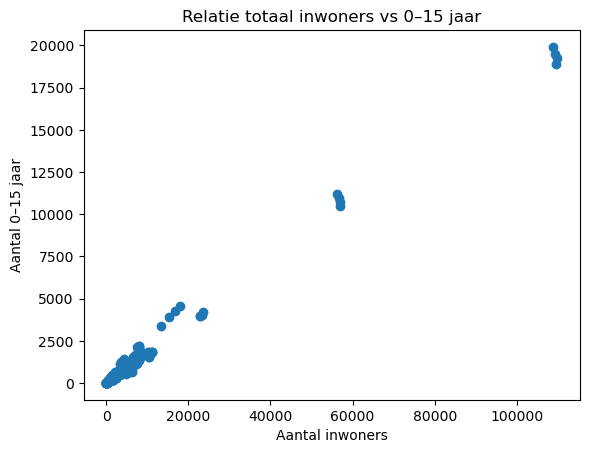

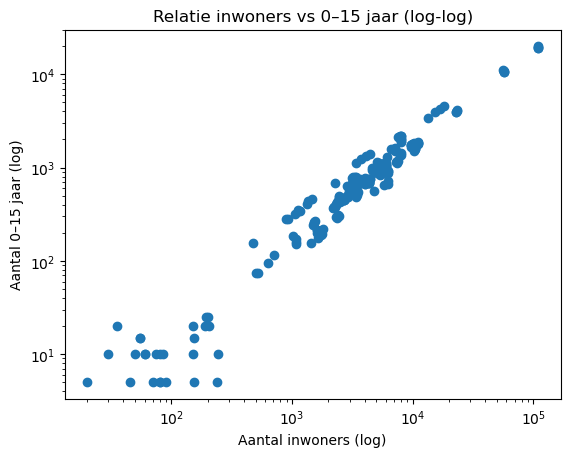

In [792]:
plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal 0–15 jaar")
plt.title("Relatie totaal inwoners vs 0–15 jaar")
plt.show()


plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Aantal inwoners (log)")
plt.ylabel("Aantal 0–15 jaar (log)")
plt.title("Relatie inwoners vs 0–15 jaar (log-log)")
plt.show()

**Toelichting**

De grafieken laten een duidelijke positieve relatie zien tussen het totaal aantal inwoners en het aantal kinderen van 0–15 jaar. Wijken met meer inwoners hebben over het algemeen ook meer kinderen. In de log-log grafiek wordt deze relatie nog duidelijker zichtbaar, omdat grote en kleine wijken beter met elkaar vergeleken kunnen worden. Dit wijst erop dat de omvang van de bevolking een belangrijke factor is voor het aantal jongeren in een wijk.

### **Trend van jongeren door de jaren (Mo)**

In deze stap onderzoeken we hoe het aantal kinderen van 0–15 jaar zich ontwikkelt over de tijd. Hiervoor bekijken we zowel het gemiddelde aantal kinderen per wijk per jaar als het totale aantal kinderen in Almere per jaar.

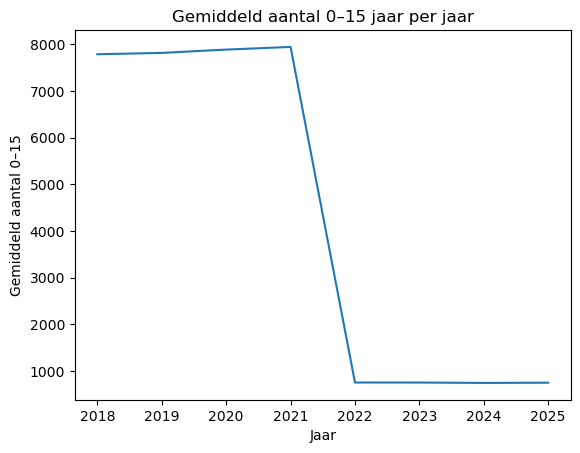

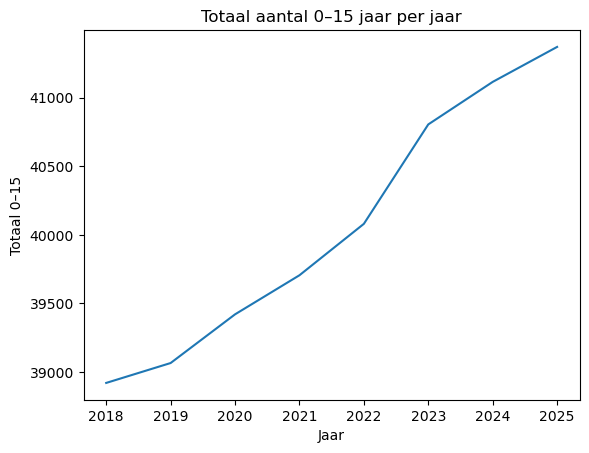

In [793]:
df.groupby("Jaar")["Aantal_0_15"].mean().plot()
plt.title("Gemiddeld aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Gemiddeld aantal 0–15")
plt.show()


df.groupby("Jaar")["Aantal_0_15"].sum().plot()
plt.title("Totaal aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Totaal 0–15")
plt.show()

**Toelichting**

De grafieken laten zien dat het totale aantal kinderen van 0–15 jaar in Almere geleidelijk toeneemt over de jaren. Dit wijst op een groei van de jeugdpopulatie in de stad. In de grafiek met het gemiddelde per wijk is een sterke daling zichtbaar vanaf 2022. Dit komt waarschijnlijk doordat vanaf dat jaar meer wijken in de dataset zijn opgenomen, waardoor het gemiddelde per wijk lager uitvalt. Daarom is het totaal aantal kinderen per jaar een betrouwbaardere indicator voor de algemene trend in de jeugdpopulatie.

### **Vergelijking tussen wijken (Faysel)**


In deze stap vergelijken we het gemiddelde aantal inwoners, kinderen (0–15 jaar) en jongeren (15–25 jaar) per wijk. Door deze grafieken te bekijken krijgen we inzicht in de verschillen tussen wijken in Almere.

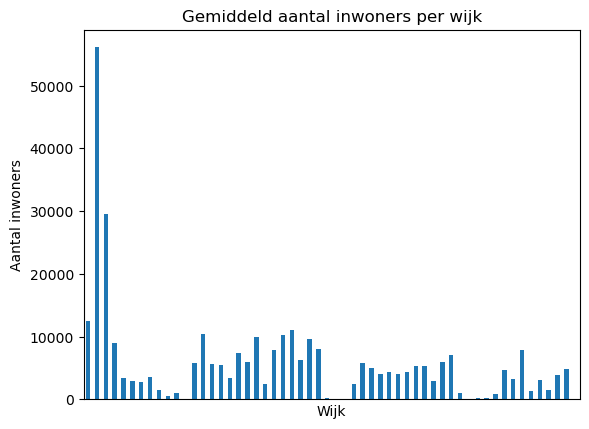

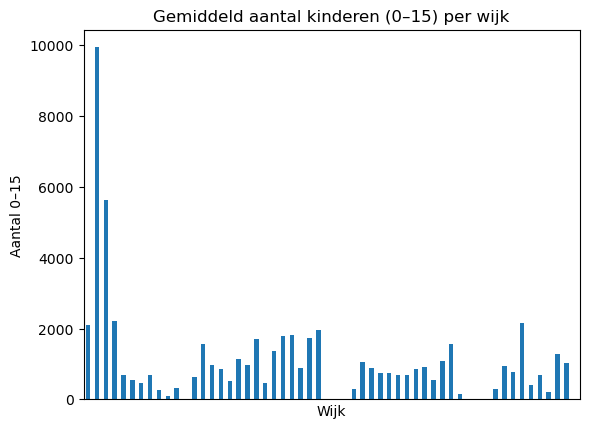

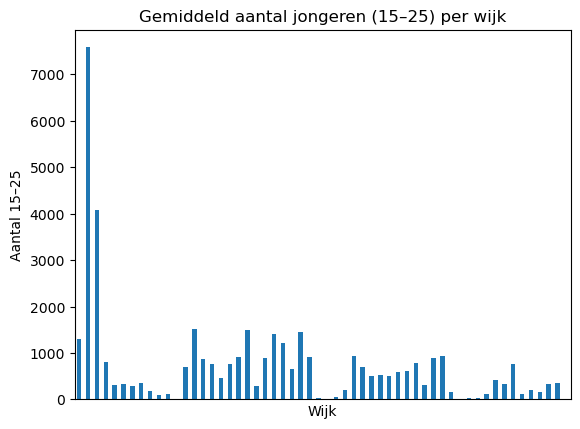

In [794]:
df.groupby("Wijk")["AantalInwoners"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal inwoners per wijk")
plt.ylabel("Aantal inwoners")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_0_15"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal kinderen (0–15) per wijk")
plt.ylabel("Aantal 0–15")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_15_25"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal jongeren (15–25) per wijk")
plt.ylabel("Aantal 15–25")
plt.xticks([])
plt.show()

**Toelichting**

De grafieken laten zien dat er grote verschillen bestaan tussen wijken in Almere. Sommige wijken hebben een veel grotere bevolking en daardoor ook meer kinderen en jongeren. Tegelijkertijd zijn er ook wijken met relatief weinig inwoners en een kleinere jeugdpopulatie.  

De patronen in de drie grafieken lijken sterk op elkaar. Wijken met veel inwoners hebben meestal ook meer kinderen en jongeren. Dit bevestigt dat de omvang van de bevolking een belangrijke factor is bij het verklaren van het aantal jongeren in een wijk.

### **Correlaties tussen variabelen (Faysal)**


In deze stap onderzoeken we de correlatie tussen het totaal aantal inwoners, het aantal kinderen van 0–15 jaar en het aantal jongeren van 15–25 jaar. Correlatie geeft aan hoe sterk twee variabelen samenhangen.

In [795]:
df[["AantalInwoners", "Aantal_0_15", "Aantal_15_25"]].corr()

,AantalInwoners,Aantal_0_15,Aantal_15_25
AantalInwoners,1.000000,0.995671,0.996897
Aantal_0_15,0.995671,1.000000,0.989825
Aantal_15_25,0.996897,0.989825,1.000000


**Toelichting**

De correlatiematrix laat zien dat er een zeer sterke positieve relatie bestaat tussen het totaal aantal inwoners en het aantal jongeren in beide leeftijdsgroepen. De correlaties liggen allemaal boven de 0.98. Dit betekent dat wijken met meer inwoners vrijwel altijd ook meer kinderen en jongeren hebben.

Dit bevestigt dat de omvang van de bevolking een belangrijke factor is bij het verklaren van het aantal jongeren in een wijk. Tegelijkertijd betekent deze sterke samenhang ook dat sommige variabelen mogelijk vergelijkbare informatie bevatten, wat belangrijk is om rekening mee te houden bij het bouwen van een model.

### **Percentage jeugd berekenen (Ismael + Wail)**

In deze stap berekenen we het percentage kinderen (0–15 jaar) en jongeren (15–25 jaar) ten opzichte van het totaal aantal inwoners per wijk. Daarnaast berekenen we het totale percentage jeugd (0–25 jaar). Deze percentages maken het mogelijk om wijken beter met elkaar te vergelijken, ongeacht verschillen in totale bevolkingsgrootte.

In [6]:
# dataset opnieuw laden (zeker dat df bestaat)
import pandas as pd

df = pd.read_csv("../../data/processed/df_v8_ready_for_analysis.csv")

# percentages berekenen
df["pct_0_15"] = (df["Aantal_0_15"] / df["AantalInwoners"]) * 100
df["pct_15_25"] = (df["Aantal_15_25"] / df["AantalInwoners"]) * 100
df["Perc_TotaleJeugd"] = df["pct_0_15"] + df["pct_15_25"]

df[["pct_0_15", "pct_15_25", "Perc_TotaleJeugd"]].describe()

# Onmogelijke waarden (>100%)
df[df["Perc_TotaleJeugd"] > 100][
    ["Wijk", "WijkCode", "AantalInwoners", "Aantal_0_15", "Aantal_15_25", "Perc_TotaleJeugd"]
].head(10)

# Extra check: jeugd groter dan totaal (moet 0 zijn)
df[(df["Aantal_0_15"] + df["Aantal_15_25"]) > df["AantalInwoners"]].head(10)

# Filter onmogelijke rijen weg
df = df[df["Perc_TotaleJeugd"] <= 100].copy()
print("Shape na filteren onmogelijke waarden:", df.shape)
df.head()

Shape na filteren onmogelijke waarden: (236, 10)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Perc_TotaleJeugd
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692,28.060553
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377,27.803279
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692,27.883996
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988,28.240544
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312,19.877676


**Toelichting**

Na het berekenen van de percentages worden controles uitgevoerd om te kijken of er onmogelijke waarden voorkomen, zoals een totaal jeugdpercentage boven de 100% of situaties waarin het aantal jongeren groter is dan het totaal aantal inwoners. Er wordt één ongeldige rij gevonden en verwijderd. Na deze opschoning bevat de dataset 236 rijen en is deze geschikt voor verdere analyse.

### **Top 10 wijken met hoogste jeugdpercentage (Wail)**

In deze stap berekenen we per wijk het gemiddelde percentage jeugd (0–25 jaar). Vervolgens selecteren we de tien wijken met het hoogste aandeel jongeren. Dit helpt om te zien in welke wijken relatief veel jongeren wonen.

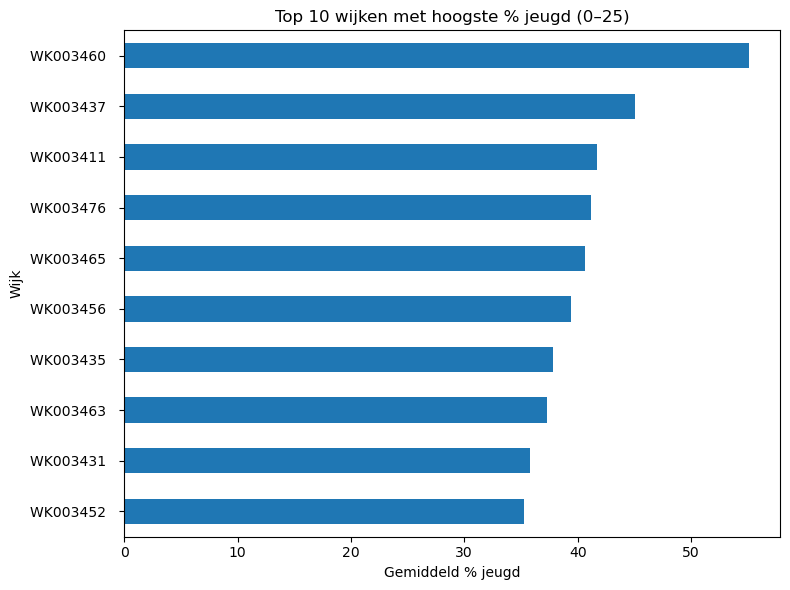

In [797]:
gemiddeld_wijk = df.groupby("Wijk")["Perc_TotaleJeugd"].mean()
top10_wijk = gemiddeld_wijk.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10_wijk.sort_values().plot(kind="barh")
plt.title("Top 10 wijken met hoogste % jeugd (0–25)")
plt.xlabel("Gemiddeld % jeugd")
plt.tight_layout()
plt.show()

**Toelichting**

De grafiek laat zien dat sommige wijken een relatief hoog aandeel jongeren hebben in vergelijking met andere wijken. In deze top 10 bestaat meer dan ongeveer 35% tot ruim 50% van de bevolking uit jongeren van 0–25 jaar. Dit betekent dat deze wijken relatief jong zijn en mogelijk een grotere behoefte hebben aan voorzieningen zoals scholen, sportfaciliteiten en jeugdzorg.

**Tijdreeks per wijk (Bo + Ismael)**

In deze stap berekenen we het totale aantal jongeren (0–25 jaar) per wijk door het aantal kinderen (0–15 jaar) en jongeren (15–25 jaar) bij elkaar op te tellen. Vervolgens bepalen we welke tien wijken gemiddeld de meeste jongeren hebben.

In [798]:
# Totale jeugd berekenen
df["Totale_Jeugd"] = df["Aantal_0_15"] + df["Aantal_15_25"]

# Top 10 wijken bepalen
top10_wijken = (
    df.groupby("Wijk")["Totale_Jeugd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("Top 10 wijken:", list(top10_wijken))

Top 10 wijken: ['WK003402  ', 'WK003403  ', 'WK003401  ', 'WK003427  ', 'WK003424  ', 'WK003430  ', 'WK003418  ', 'WK003428  ', 'WK003404  ', 'WK003463  ']


**Toelichting**

De resultaten laten zien welke wijken gemiddeld de grootste jeugdpopulatie hebben. Dit zijn voornamelijk de grotere wijken in Almere waar relatief veel inwoners wonen. Omdat deze wijken ook meer jongeren hebben, kunnen ze een grotere vraag hebben naar voorzieningen zoals scholen, sportfaciliteiten en jeugdzorg.

### **Ontwikkeling van 15–25 jarigen in de top 10 wijken**

In deze stap analyseren we hoe het aantal jongeren van 15–25 jaar zich ontwikkelt door de jaren heen in de tien wijken met de grootste jeugdpopulatie. Door deze ontwikkeling per wijk te visualiseren kunnen we trends en veranderingen in de jeugdpopulatie beter begrijpen.

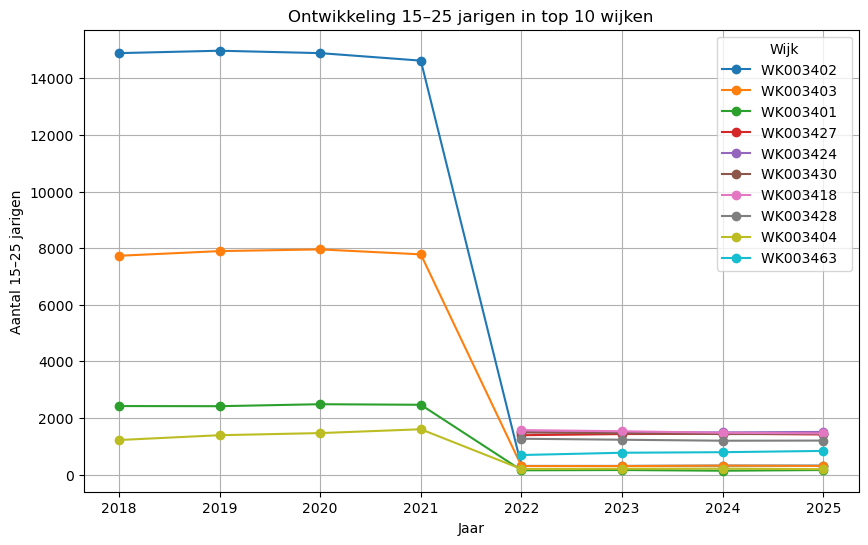

In [799]:
plt.figure(figsize=(10,6))

for wijk in top10_wijken:
    
    subset = df[df["Wijk"] == wijk].sort_values("Jaar")

    plt.plot(
        subset["Jaar"],
        subset["Aantal_15_25"],
        marker="o",
        label=wijk
    )

plt.xlabel("Jaar")
plt.ylabel("Aantal 15–25 jarigen")
plt.title("Ontwikkeling 15–25 jarigen in top 10 wijken")

plt.legend(title="Wijk")
plt.grid(True)

plt.show()

**Toelichting**

De grafiek laat zien dat sommige wijken een duidelijk hoger aantal jongeren hebben dan andere wijken. Daarnaast is te zien dat er vanaf 2022 een sterke daling zichtbaar is in enkele wijken. Dit kan komen door veranderingen in de wijkindeling of doordat nieuwe, kleinere wijken in de dataset zijn opgenomen. Hierdoor lijken de aantallen per wijk lager, terwijl de totale jeugdpopulatie in Almere niet per se is afgenomen. De grafiek laat vooral zien dat de ontwikkeling van jongeren per wijk sterk kan verschillen.

### **Bo’s stadsdeel mapping (alleen als WijkCode WK003401 etc.)**

In deze stap worden de wijken gekoppeld aan de stadsdelen van Almere. Vervolgens analyseren we hoe het aantal kinderen van 0–15 jaar zich ontwikkelt per stadsdeel over de jaren. Dit helpt om verschillen in jeugdontwikkeling tussen de verschillende delen van de stad zichtbaar te maken.

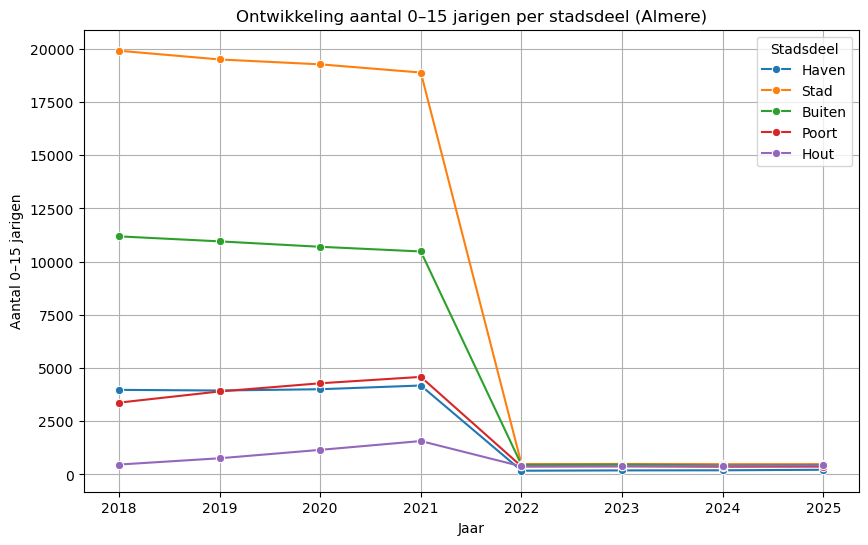

In [800]:
# Mapping wijkcodes -> stadsdelen
wijk_mapping = {
    "WK003401": "Haven",
    "WK003402": "Stad",
    "WK003403": "Buiten",
    "WK003404": "Poort",
    "WK003405": "Hout",
}

df["Stadsdeel"] = df["WijkCode"].map(wijk_mapping)

df_map = df.dropna(subset=["Stadsdeel"]).copy()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_map,
    x="Jaar",
    y="Aantal_0_15",
    hue="Stadsdeel",
    marker="o"
)

plt.title("Ontwikkeling aantal 0–15 jarigen per stadsdeel (Almere)")
plt.xlabel("Jaar")
plt.ylabel("Aantal 0–15 jarigen")

plt.grid(True)

plt.legend(title="Stadsdeel")

plt.show()

**Toelichting**

De grafiek laat zien dat de stadsdelen duidelijke verschillen hebben in het aantal kinderen van 0–15 jaar. Stadsdeel Stad en Buiten hebben het hoogste aantal kinderen, terwijl Hout duidelijk minder kinderen heeft. Daarnaast is vanaf 2022 een sterke daling zichtbaar. Dit komt waarschijnlijk doordat de wijkindeling in de dataset verandert, waardoor de aantallen per stadsdeel anders worden verdeeld. Ondanks deze verandering blijft zichtbaar dat sommige stadsdelen structureel meer jongeren hebben dan andere.

# Fase 3 – Data Preparation

In deze fase wordt de dataset voorbereid voor modellering. De analyseklare dataset uit fase 2 wordt uitgebreid met nieuwe features die gebruikt kunnen worden in het regressiemodel.

De input van deze fase is:

`../../data/processed/df_v8_ready_for_analysis.csv`

Het doel is om de dataset model-klaar te maken. Binnen deze fase zijn door verschillende teamleden aanvullende features en controles uitgevoerd. Deze onderdelen worden hieronder stap voor stap samengebracht.

De uiteindelijke output van deze fase is:

`../../data/processed/df_v12_model_ready.csv`

## 3.1 Basisdataset laden

We starten vanuit de analyseklare dataset uit fase 2. Deze dataset bevat per wijk en per jaar de belangrijkste demografische variabelen die als basis dienen voor verdere feature engineering.

In [801]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


In [802]:
df_base[["Wijk", "Jaar"]].head()

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022


In [803]:
df_base.duplicated(subset=["Wijk", "Jaar"]).sum()

np.int64(0)

De controle op `Wijk` + `Jaar` laat zien of iedere combinatie uniek voorkomt. Dit is belangrijk, omdat de verschillende feature-datasets later op deze sleutel worden samengevoegd.

## 3.2 Ratio jongeren ten opzichte van totale bevolking (Ismael)

In deze stap worden relatieve indicatoren berekend om wijken eerlijker met elkaar te kunnen vergelijken. Absolute aantallen jongeren kunnen stijgen doordat de totale bevolking groeit, maar zeggen minder over de werkelijke demografische samenstelling. Daarom wordt het aantal jongeren gedeeld door het totaal aantal inwoners.

In [804]:
df = pd.read_csv("../../data/processed/df_v8_ready_for_analysis.csv")
df.columns = df.columns.astype(str).str.strip()

# Peildatum -> Jaar
df["Peildatum"] = pd.to_datetime(df["Peildatum"], dayfirst=True, errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

# Alleen consistente jaren
df = df[df["Jaar"] <= 2021].copy()

# wijkcodes opschonen
df["Wijk"] = df["Wijk"].astype(str).str.strip()

# Ratio's
df["Ratio_0_15"] = df["Aantal_0_15"] / df["AantalInwoners"]
df["Ratio_15_25"] = df["Aantal_15_25"] / df["AantalInwoners"]

# Checks
print("Min/Max Ratio 0–15:", df["Ratio_0_15"].min(), df["Ratio_0_15"].max())
print("Min/Max Ratio 15–25:", df["Ratio_15_25"].min(), df["Ratio_15_25"].max())

Min/Max Ratio 0–15: 0.17207303974221266 0.25566825775656327
Min/Max Ratio 15–25: 0.08333333333333333 0.13963489555906616


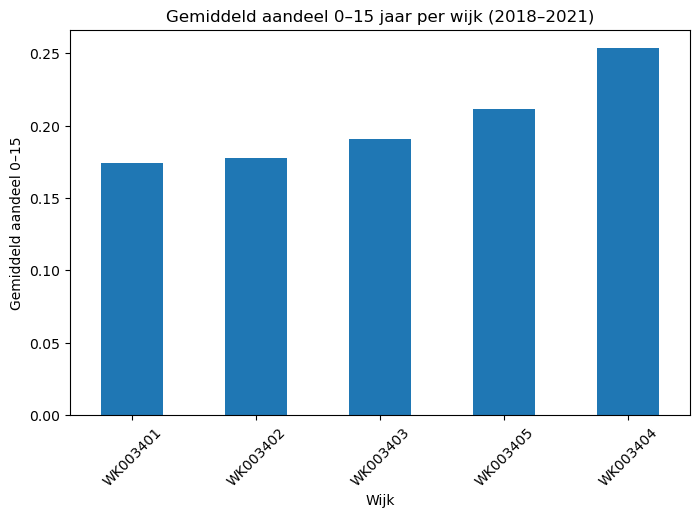

In [805]:
gemiddeld_0 = df.groupby("Wijk")["Ratio_0_15"].mean().sort_values()

plt.figure(figsize=(8,5))
gemiddeld_0.plot(kind="bar")

plt.ylabel("Gemiddeld aandeel 0–15")
plt.title("Gemiddeld aandeel 0–15 jaar per wijk (2018–2021)")
plt.xticks(rotation=45)
plt.show()

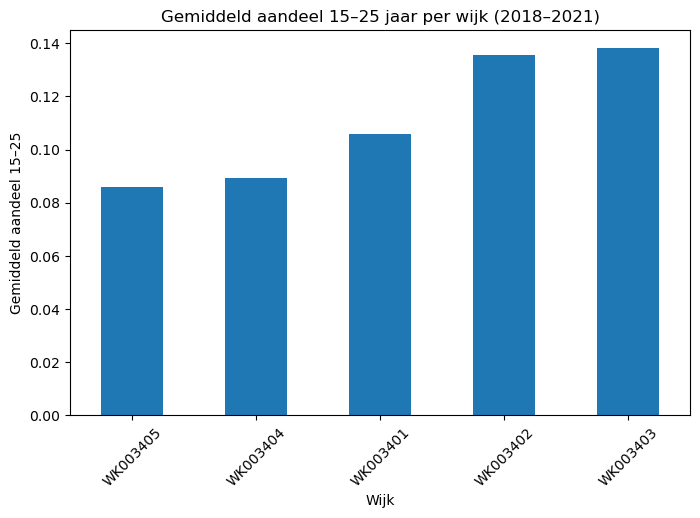

In [806]:
gemiddeld_1 = df.groupby("Wijk")["Ratio_15_25"].mean().sort_values()

plt.figure(figsize=(8,5))
gemiddeld_1.plot(kind="bar")

plt.ylabel("Gemiddeld aandeel 15–25")
plt.title("Gemiddeld aandeel 15–25 jaar per wijk (2018–2021)")
plt.xticks(rotation=45)
plt.show()

In [807]:
df.to_csv("../../data/processed/df_v10_ratio_temp.csv", index=False)

De ratio-features laten het aandeel jongeren binnen de totale bevolking zien. Daarmee kunnen verschillen tussen wijken beter worden geïnterpreteerd dan met alleen absolute aantallen.

## 3.3 Stabiliteit en plausibiliteit van ratio-features controleren (Ismael)

Na het berekenen van de ratio’s wordt gecontroleerd of deze nieuwe variabelen technisch correct en inhoudelijk plausibel zijn. Hierbij wordt gekeken naar onmogelijke waarden, null-waarden en deling door nul.

In [808]:
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")
df.columns = df.columns.astype(str).str.strip()

print("Start aantal rijen:", len(df))

print("\nControle ratio > 1:")
print("Ratio_0_15 > 1:", (df["Ratio_0_15"] > 1).sum())
print("Ratio_15_25 > 1:", (df["Ratio_15_25"] > 1).sum())

print("\nControle ratio < 0:")
print("Ratio_0_15 < 0:", (df["Ratio_0_15"] < 0).sum())
print("Ratio_15_25 < 0:", (df["Ratio_15_25"] < 0).sum())

print("\nAantal NaN waarden:")
print(df[["Ratio_0_15", "Ratio_15_25"]].isna().sum())

print("\nAantal rijen met inwoners = 0:")
print((df["AantalInwoners"] == 0).sum())

Start aantal rijen: 20

Controle ratio > 1:
Ratio_0_15 > 1: 0
Ratio_15_25 > 1: 0

Controle ratio < 0:
Ratio_0_15 < 0: 0
Ratio_15_25 < 0: 0

Aantal NaN waarden:
Ratio_0_15     0
Ratio_15_25    0
dtype: int64

Aantal rijen met inwoners = 0:
0


In [809]:
df_clean = df[
    (df["AantalInwoners"] > 0) &
    (df["Ratio_0_15"].between(0,1)) &
    (df["Ratio_15_25"].between(0,1))
].copy()

print("\nAantal rijen na cleaning:", len(df_clean))


Aantal rijen na cleaning: 20


Uit deze controle blijkt of de berekende ratio-features bruikbaar zijn voor verdere analyse en modellering.

## 3.4 Lag-feature maken op basis van vorige waarde (Wail)

In deze stap wordt een lag-feature gemaakt. Een lag-feature gebruikt een waarde van het vorige jaar als voorspeller voor het huidige jaar. Dit kan helpen om trends in de data beter te modelleren.

In [810]:
import pandas as pd

input_path = "../../data/processed/df_v8_ready_for_analysis.csv"
df = pd.read_csv(input_path)

print(df.shape)
df.head()

(237, 9)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


In [811]:
df = df.sort_values(["Wijk", "Jaar"])

df["Jeugdzorg"] = df["Aantal_0_15"] + df["Aantal_15_25"]

df["Jeugdzorg_lag1"] = df.groupby("Wijk")["Jeugdzorg"].shift(1)

df.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Jeugdzorg,Jeugdzorg_lag1
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692,6395,NaN
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377,6360,6395.0
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692,6490,6360.0
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988,6645,6490.0
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312,325,6645.0


In [812]:
df = df.dropna(subset=["Jeugdzorg_lag1"])

print(df.shape)

(181, 11)


In [813]:
output_path = "../../data/processed/df_v12_model_ready.csv"
df.to_csv(output_path, index=False)

print("Dataset opgeslagen:", output_path)

Dataset opgeslagen: ../../data/processed/df_v12_model_ready.csv


Met `groupby("Wijk")` wordt de lag alleen binnen dezelfde wijk berekend. De functie `shift(1)` verschuift de waarden één jaar naar beneden, zodat de waarde van het vorige jaar beschikbaar wordt als nieuwe variabele.

## 3.5 Groei van leeftijdsgroepen per wijk analyseren (Bo)

In dit onderdeel wordt gekeken naar de ontwikkeling van de leeftijdsgroepen 0–15 jaar en 15–25 jaar tussen 2018 en 2021. De groei wordt zowel absoluut als procentueel weergegeven.

In [814]:
df_groei = pd.read_csv('../../data/processed/df_v10_ratio_temp.csv')
wijk_mapping = {
    "WK003401": "Haven",
    "WK003402": "Stad",
    "WK003403": "Buiten",
    "WK003404": "Poort",
    "WK003405": "Hout",
}

df_groei["Stadsdeel"] = df_groei["Wijk"].map(wijk_mapping)

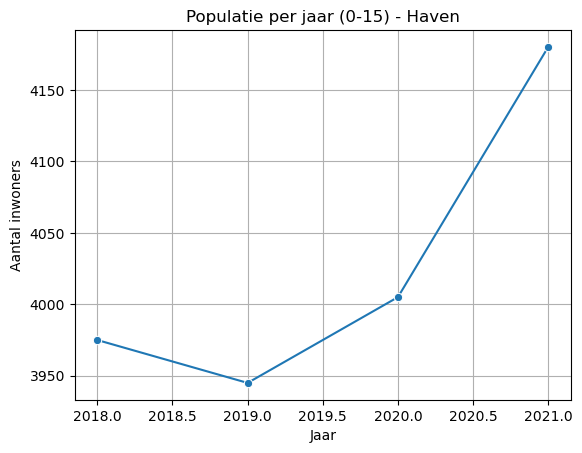

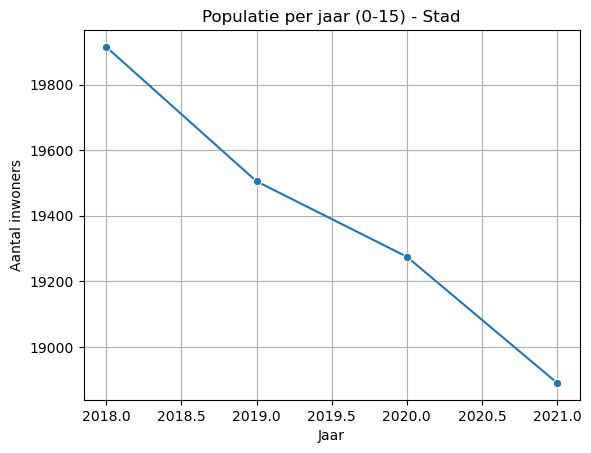

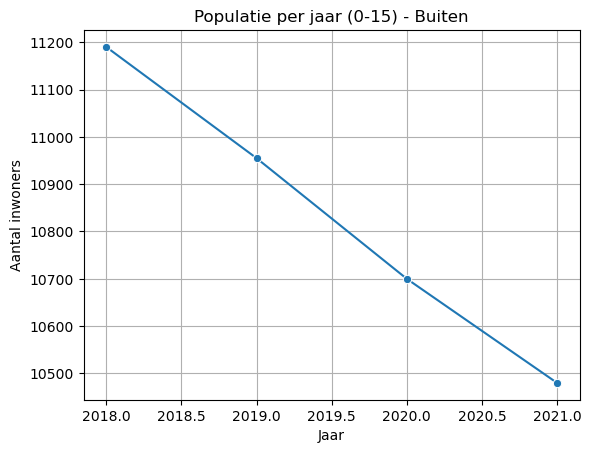

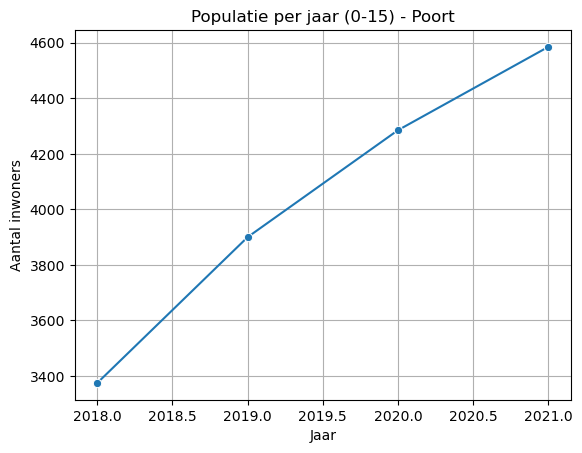

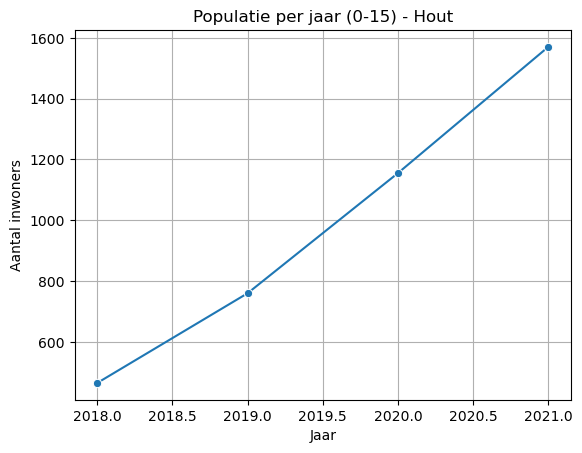

In [815]:
import matplotlib.pyplot as plt
import seaborn as sns

for wijk in df_groei["Stadsdeel"].unique():
    plt.figure()
    
    subset1 = df_groei[df_groei["Stadsdeel"] == wijk]
    
    ax = sns.lineplot(
        data=subset1,
        x="Jaar",
        y="Aantal_0_15",
        marker="o"
    )
    
    ax.grid(True)
    plt.title(f"Populatie per jaar (0-15) - {wijk}")
    plt.xlabel("Jaar")
    plt.ylabel("Aantal inwoners")
    plt.show()

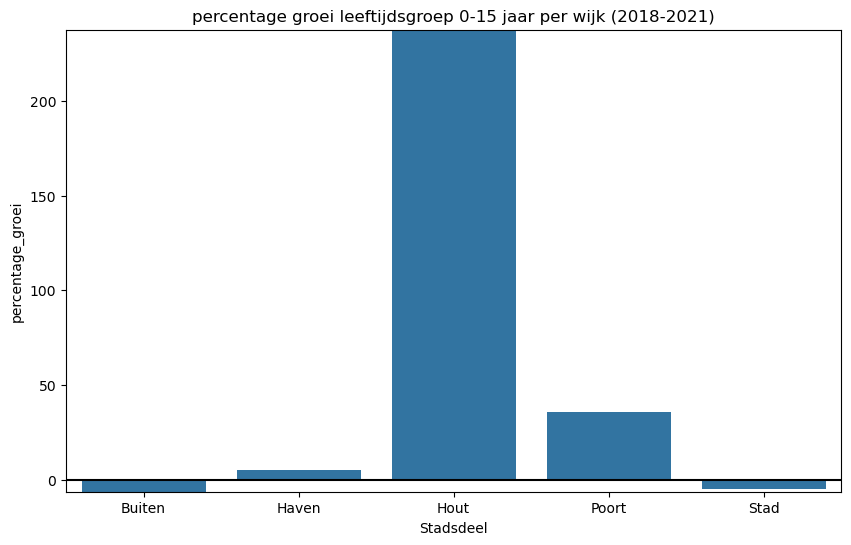

In [816]:
subset2 = df_groei

subset2['Peildatum'] = pd.to_datetime(subset2['Peildatum'])

subset2 = subset2[subset2['Jaar'].isin([2018, 2021])]

subset2 = subset2.pivot(index='Stadsdeel', columns='Jaar', values='Aantal_0_15')

subset2["groei"] = subset2[2021] - subset2[2018]

subset2["percentage_groei"] = (subset2["groei"] / subset2[2018]) * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset2.reset_index(),
    x='Stadsdeel',
    y='percentage_groei',
)

plt.title('percentage groei leeftijdsgroep 0-15 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset2['percentage_groei'].min(), subset2['percentage_groei'].max())
plt.show()

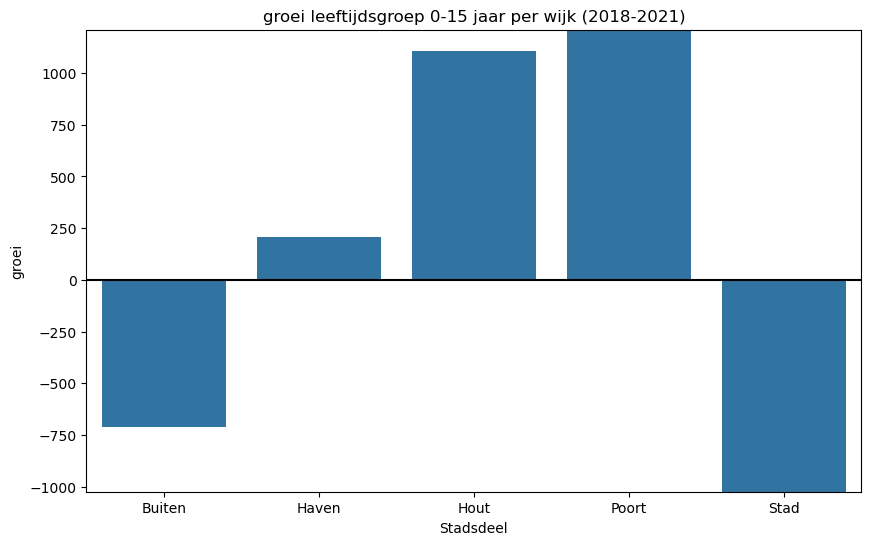

In [817]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset2.reset_index(),
    x='Stadsdeel',
    y='groei',
)

plt.title('groei leeftijdsgroep 0-15 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset2['groei'].min(), subset2['groei'].max())
plt.show()

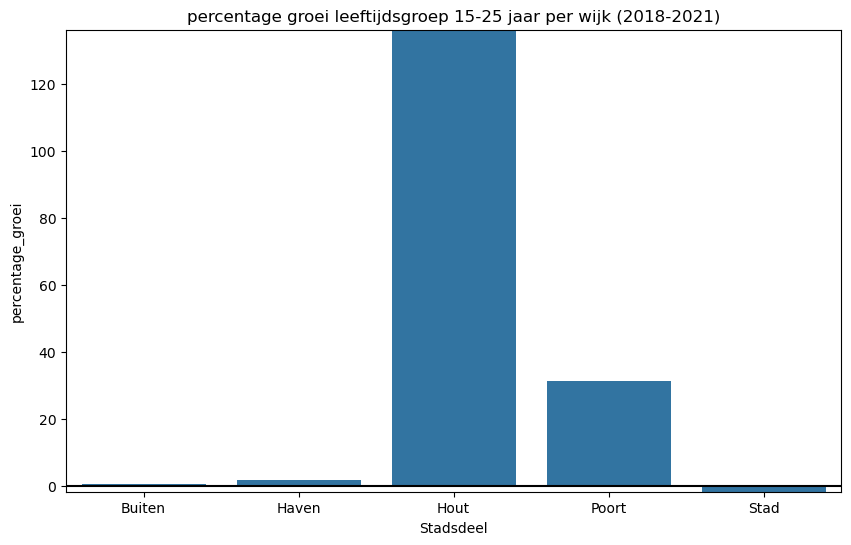

In [818]:
subset3 = df_groei

subset3['Peildatum'] = pd.to_datetime(subset3['Peildatum'])

subset3 = subset3[subset3['Jaar'].isin([2018, 2021])]

subset3 = subset3.pivot(index='Stadsdeel', columns='Jaar', values='Aantal_15_25')

subset3["groei"] = subset3[2021] - subset3[2018]

subset3["percentage_groei"] = (subset3["groei"] / subset3[2018]) * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset3.reset_index(),
    x='Stadsdeel',
    y='percentage_groei',
)

plt.title('percentage groei leeftijdsgroep 15-25 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset3['percentage_groei'].min(), subset3['percentage_groei'].max())
plt.show()

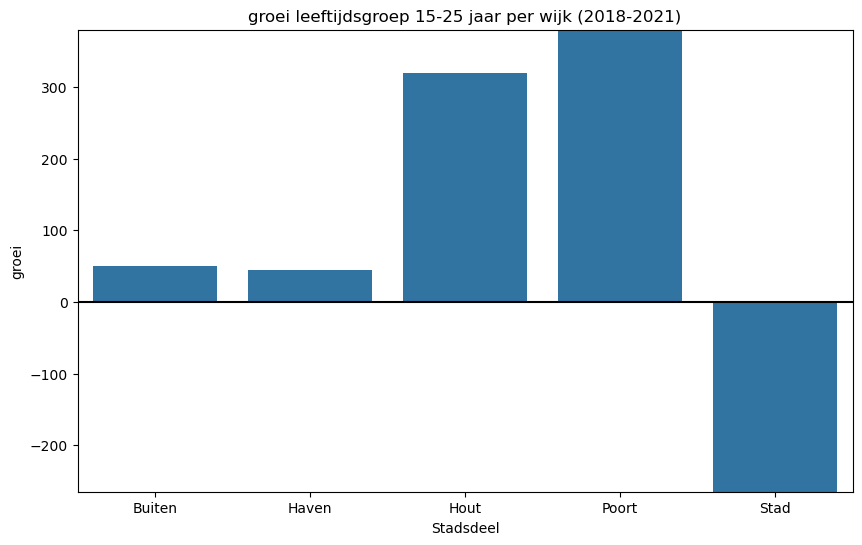

In [819]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset3.reset_index(),
    x='Stadsdeel',
    y='groei',
)

plt.title('groei leeftijdsgroep 15-25 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset3['groei'].min(), subset3['groei'].max())
plt.show()

In [820]:
subset4 = df_groei

subset4['Peildatum'] = pd.to_datetime(subset4['Peildatum'])

subset4 = subset4[subset4['Jaar'].isin([2018, 2021])]

subset4 = subset4.pivot(index='Stadsdeel', columns='Jaar', values='AantalInwoners')

subset4["groei"] = subset4[2021] - subset4[2018]

subset4["percentage_groei"] = (subset4["groei"] / subset4[2018]) * 100

Dit onderdeel laat per stadsdeel zien hoe de leeftijdsgroepen en de totale bevolking zich tussen 2018 en 2021 hebben ontwikkeld.

## 3.6 Correlatiematrix en multicollineariteit analyseren (Mohammed)

In deze stap wordt onderzocht hoe de verschillende numerieke variabelen met elkaar samenhangen. Dit helpt bij het herkennen van mogelijke multicollineariteit, waarbij meerdere variabelen vrijwel dezelfde informatie bevatten.

In [821]:
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")

df.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,2018,WK003402,WK003402,108800,19915,14890,18.304228,13.685662,0.183042,0.136857


In [822]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

corr_matrix

,Jaar,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
Jaar,1.000000,0.021245,0.009155,0.007600,0.096953,-0.042248,0.096953,-0.042248
AantalInwoners,0.021245,1.000000,0.996688,0.998529,-0.503183,0.867106,-0.503183,0.867106
Aantal_0_15,0.009155,0.996688,1.000000,0.995371,-0.447969,0.868357,-0.447969,0.868357
Aantal_15_25,0.007600,0.998529,0.995371,1.000000,-0.511022,0.879091,-0.511022,0.879091
pct_0_15,0.096953,-0.503183,-0.447969,-0.511022,1.000000,-0.625288,1.000000,-0.625288
pct_15_25,-0.042248,0.867106,0.868357,0.879091,-0.625288,1.000000,-0.625288,1.000000
Ratio_0_15,0.096953,-0.503183,-0.447969,-0.511022,1.000000,-0.625288,1.000000,-0.625288
Ratio_15_25,-0.042248,0.867106,0.868357,0.879091,-0.625288,1.000000,-0.625288,1.000000


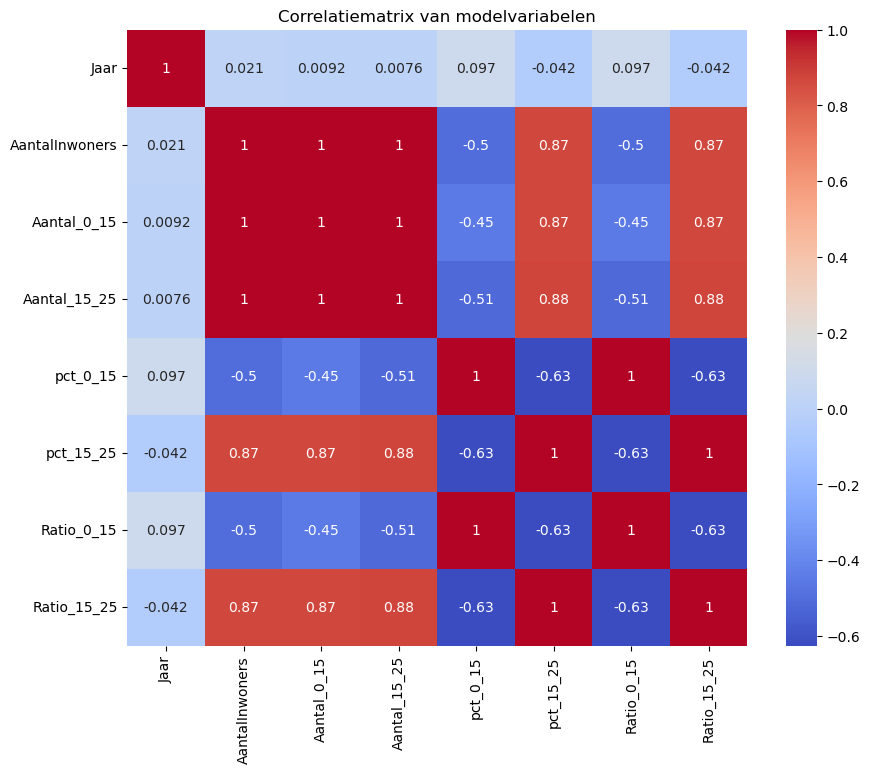

In [823]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlatiematrix van modelvariabelen")
plt.show()

De correlatiematrix laat zien welke variabelen sterk samenhangen. Dit is belangrijk om te beoordelen welke variabelen later geschikt zijn voor gebruik in het model.

## 3.7 Noah Dataset Finaliseren
 Voor modellering  mogen meestal alleen numerieke variabelen gebruikt worden.

Niet-numerieke kolommen zoals:

Wijknamen (tekst)

Datums

Eventuele categorieën

kunnen een model verstoren of errors geven.

Daarom:

1️ We behouden alleen numerieke kolommen
2️ We verwijderen overbodige variabelen
3️ We controleren nog een keer op missende waarden
4️ We maken een definitieve dataset

In [ ]:
#controle bestand inleezen en kijken of alle waardes numeriek zijn
import pandas as pd
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")
df.head()

df.dtypes

In [ ]:
# Peildatum omzetten naar datetime zodat we peildatum numeriek kunnen maken
df['Peildatum'] = pd.to_datetime(df['Peildatum'])

# Jaar extraheren
df['jaar'] = df['Peildatum'].dt.year

Nu hebben we van peildatum "jaar" gemaakt met een numerieke waarden nu kunnen we de oude verie deleten oftewel peildatm en dit gaan we gelijk controleren

In [ ]:
df = df.drop(columns=['Peildatum'])
#controleren of peildatum weg is en de numerieke vervaning jaar ook daadwerkelijk numeriek is
df.dtypes


In [ ]:
# isna() markeert elke cel als True (bij NaN) of False, en sum() telt vervolgens alle True waardes op per kolom. zo controleren we of er nog NaN waardes zijn bij laatste dataset
df.isna().sum()

## 3.8 Features samenvoegen tot één modeldataset (Faysal)

In deze stap worden de beschikbare feature-datasets samengevoegd tot één modelklare dataset. De merge gebeurt op de sleutel `Wijk` en `Jaar`.

In [824]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


In [825]:
df_base[["Wijk","Jaar"]].head()

df_base.duplicated(subset=["Wijk","Jaar"]).sum()

np.int64(0)

In [826]:
ratio_path = Path("../../data/processed/df_v10_ratio_temp.csv")

df_ratio = pd.read_csv(ratio_path)

df_ratio.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,2018,WK003402,WK003402,108800,19915,14890,18.304228,13.685662,0.183042,0.136857


In [827]:
df_ratio = df_ratio[[
    "Wijk",
    "Jaar",
    "Ratio_0_15",
    "Ratio_15_25"
]]

df_ratio.head()

,Wijk,Jaar,Ratio_0_15,Ratio_15_25
0,WK003401,2018,0.174419,0.106187
1,WK003401,2019,0.172459,0.105574
2,WK003401,2020,0.172073,0.106767
3,WK003401,2021,0.177646,0.104760
4,WK003402,2018,0.183042,0.136857


In [828]:
df_base["Wijk"] = df_base["Wijk"].astype(str).str.strip()
df_ratio["Wijk"] = df_ratio["Wijk"].astype(str).str.strip()

df_base["Jaar"] = df_base["Jaar"].astype(int)
df_ratio["Jaar"] = df_ratio["Jaar"].astype(int)
df_merged = df_base.merge(
    df_ratio,
    on=["Wijk","Jaar"],
    how="left"
)

df_merged.head()

,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988,0.177646,0.104760
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312,NaN,NaN


In [829]:
print("Rows base:", len(df_base))
print("Rows merged:", len(df_merged))

df_merged.isnull().sum()

Rows base: 237
Rows merged: 237


Peildatum           0
Jaar                0
WijkCode            0
Wijk                0
AantalInwoners      0
Aantal_0_15         0
Aantal_15_25        0
pct_0_15            0
pct_15_25           0
Ratio_0_15        217
Ratio_15_25       217
dtype: int64

In [830]:
df_base.dtypes
df_ratio.dtypes

Wijk            object
Jaar             int64
Ratio_0_15     float64
Ratio_15_25    float64
dtype: object

In [831]:
df_ratio = df_ratio[df_ratio["Jaar"].isin(df_base["Jaar"].unique())].copy()

print("Jaren base:", sorted(df_base["Jaar"].unique()))
print("Jaren ratio (na filter):", sorted(df_ratio["Jaar"].unique()))

Jaren base: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Jaren ratio (na filter): [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [832]:
model_cols = [
    "Wijk",
    "Jaar",
    "AantalInwoners",
    "Aantal_0_15",
    "Aantal_15_25",
    "Ratio_0_15",
    "Ratio_15_25"
]

df_model = df_merged[model_cols].copy()

df_model.head()

,Wijk,Jaar,AantalInwoners,Aantal_0_15,Aantal_15_25,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


In [833]:
matches = df_merged[["Ratio_0_15", "Ratio_15_25"]].notna().all(axis=1).sum()
totaal = len(df_merged)

print("Aantal rijen met ratio's gevuld:", matches, "van", totaal)
print("Aantal rijen zonder ratio's:", totaal - matches)

Aantal rijen met ratio's gevuld: 20 van 237
Aantal rijen zonder ratio's: 217


In [834]:
df_model.dtypes

Wijk               object
Jaar                int64
AantalInwoners      int64
Aantal_0_15         int64
Aantal_15_25        int64
Ratio_0_15        float64
Ratio_15_25       float64
dtype: object

In [835]:
output_path = Path("../../data/processed/df_v12_model_ready.csv")

df_model.to_csv(output_path, index=False)

output_path

PosixPath('../../data/processed/df_v12_model_ready.csv')

In [836]:
df_model.groupby("Wijk")["Jaar"].min(), df_model.groupby("Wijk")["Jaar"].max()

(Wijk
 WK003401    2018
 WK003402    2018
 WK003403    2018
 WK003404    2018
 WK003405    2018
 WK003406    2022
 WK003407    2022
 WK003408    2022
 WK003409    2022
 WK003410    2022
 WK003411    2022
 WK003414    2022
 WK003417    2022
 WK003418    2022
 WK003419    2022
 WK003420    2022
 WK003421    2022
 WK003422    2022
 WK003423    2022
 WK003424    2022
 WK003425    2022
 WK003426    2022
 WK003427    2022
 WK003428    2022
 WK003429    2022
 WK003430    2022
 WK003431    2022
 WK003432    2024
 WK003435    2023
 WK003437    2022
 WK003441    2022
 WK003442    2022
 WK003443    2022
 WK003444    2022
 WK003445    2022
 WK003446    2022
 WK003447    2022
 WK003448    2022
 WK003449    2022
 WK003450    2022
 WK003451    2022
 WK003452    2022
 WK003453    2022
 WK003456    2022
 WK003458    2022
 WK003459    2025
 WK003460    2022
 WK003461    2022
 WK003462    2022
 WK003463    2022
 WK003465    2022
 WK003466    2022
 WK003475    2022
 WK003476    2022
 WK003477    2022
 WK0

In [837]:
df_ratio["Jaar"].unique()
df_base["Jaar"].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

Na het samenvoegen wordt gecontroleerd of het aantal rijen gelijk blijft, hoeveel matches daadwerkelijk zijn gevonden en of de modelvariabelen het juiste datatype hebben. De uiteindelijke dataset wordt opgeslagen als `df_v12_model_ready.csv`.

## Modeling
We gebruiken lineaire regressie als baseline model.

## Evaluatie

## Visualisatie Resultaten

## Conclusie
- Hoe goed presteert het model?
- Is het bruikbaar voor de gemeente?
- Wat zijn beperkingen?
- Aanbevelingen voor vervolgonderzoek.